In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

In [3]:
pd.options.display.float_format = '{:20,.2f}'.format

In [74]:
countries = gpd.read_file(r"UN_Countries_Simplified.shp")
countries= countries.rename(columns={"iso3cd":"country"})

In [75]:
countries = countries[["nam_en", "country"]]

In [73]:
countries_list = ["ALB", "BGD", "BOL", "BTN", "BRN","CYP", "ECU", "ETH", "B35", "GRC", "HUN", "IND", "KEN","KOR",
             "MAR", "MKD", "MNE", "NGA", "NZ1", "PNG", "SAU", "TUR", "TZA", "US1", "VNM"]

In [6]:
absolutes_data("AFG").sum()

months              2020-012020-022020-032020-042020-052020-062020...
Edits                                                         3628630
Contributors                                                     8854
Changesets                                                     129135
ContributorsAI                                                 252.00
EditsAI                                                     84,966.00
ChangesetsAI                                                 2,391.00
editsPerc                                                      330.29
changesetsPerc                                                 205.62
contributorsPerc                                               224.25
country             AFGAFGAFGAFGAFGAFGAFGAFGAFGAFGAFGAFGAFGAFGAFGA...
dtype: object

In [7]:
(84966/3628630)*100

2.3415448805747623

In [4]:
def absolutes_data(country):
    #the updated indicator list from Creating_final_fixed_idnicator_csv.ipynb
    df = pd.read_csv(rf"..\data\ouput\country_analysis\v5_indicators\{country}\{country}_monthly_stats.csv")
    df = df.loc[(df["months"] <="2025-12" ) & (df["months"] >"2019-12" )]
    df["country"] =f"{country}"
    df = df[['months', 'Edits', 'Contributors', 'Changesets','ContributorsAI', 'EditsAI', 'ChangesetsAI',
       'editsPerc', 'changesetsPerc', 'contributorsPerc', 'country']]
    return df

In [76]:
dfs_total = []

for c in countries_list:
    dfb = absolutes_data(c)
    dfs_total.append(dfb)

result_all_totals = pd.concat(dfs_total, ignore_index=True)

In [77]:
df = result_all_totals.rename(columns={"editsPerc":"edits_perc"})

#### Monthly coutnry plots

In [78]:
df = df.sort_values(by="edits_perc", ascending = False)

In [79]:
df_pivot = df.pivot(index="months", columns="country", values="edits_perc")

In [80]:
sorted_indices = df_pivot.sum(axis=0).values.argsort()
df_pivot = df_pivot.iloc[:, sorted_indices]

In [81]:
df_pivot

country,BRN,BTN,KOR,CYP,MKD,ECU,MNE,B35,SAU,MAR,...,ETH,KEN,ALB,VNM,NZ1,US1,PNG,BOL,IND,TZA
months,,,,,,,,,,,,,,,,,,,,,
2020-01,82.64,0.00,4.41,0.00,0.00,0.26,0.00,0.17,2.38,1.40,...,29.36,0.81,0.02,23.75,0.15,5.64,0.00,39.85,2.35,29.01
2020-02,41.14,0.00,0.29,0.00,0.00,0.00,0.00,0.00,0.10,0.01,...,45.66,0.91,0.03,78.03,0.00,4.49,0.00,38.11,5.64,49.02
2020-03,0.26,0.00,4.12,0.00,17.16,0.11,0.00,0.00,3.65,0.60,...,47.59,1.34,0.00,80.16,0.13,9.83,0.78,28.87,18.93,63.81
2020-04,0.00,0.00,1.65,0.17,5.24,0.00,0.00,0.00,7.92,0.00,...,15.59,1.27,0.82,79.40,0.00,12.79,0.28,28.51,25.84,67.14
2020-05,0.00,0.00,3.22,0.00,0.32,0.08,0.00,0.10,0.00,2.88,...,3.73,2.81,0.06,79.35,0.10,9.82,0.00,13.81,21.91,35.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08,0.00,0.00,3.66,1.68,0.02,2.47,0.35,0.12,0.05,1.33,...,3.38,5.36,4.49,0.00,10.29,15.16,0.04,49.95,3.38,1.70
2025-09,0.00,0.00,9.59,0.71,0.45,2.82,0.25,3.42,0.79,1.78,...,0.53,9.40,23.13,0.12,0.50,22.94,1.26,42.87,2.91,4.55
2025-10,0.00,0.09,9.99,7.87,1.50,0.47,3.78,16.49,0.12,1.55,...,0.80,5.14,71.39,0.09,0.35,22.61,0.15,20.17,1.73,0.20


**TOP 31 List** as of final coutnry list

In [82]:
df_top25 = df.sort_values(['country', 'months'])

In [84]:
df_top25 = df_top25.merge(countries, on="country", how="left")

In [85]:
df_top25["nam_en"].loc[df_top25["country"]=="US1"]="United States of America"
df_top25["nam_en"].loc[df_top25["country"]=="NZ1"]="New Zealand"
df_top25["nam_en"].loc[df_top25["country"]=="B35"]="Georgia"

C:\Users\Lilly\AppData\Local\Temp\ipykernel_7400\3542717566.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top25["nam_en"].loc[df_top25["country"]=="US1"]="United States of America"
C:\Users\Lilly\AppData\Local\Temp\ipykernel_7400\3542717566.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top25["nam_en"].loc[df_top25["country"]=="NZ1"]="New Zealand"
C:\Users\Lilly\AppData\Local\Temp\ipykernel_7400\3542717566.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexin

In [86]:
df_top25.loc[df_top25["nam_en"]==]

,months,Edits,Contributors,Changesets,ContributorsAI,EditsAI,ChangesetsAI,edits_perc,changesetsPerc,contributorsPerc,country,nam_en
0,2020-01,52344,122,2924,2.00,10.00,5.00,0.02,0.17,1.64,ALB,Albania
1,2020-02,15461,77,951,2.00,5.00,5.00,0.03,0.53,2.60,ALB,Albania
2,2020-03,22391,71,516,0.00,0.00,0.00,0.00,0.00,0.00,ALB,Albania
3,2020-04,15021,47,313,2.00,123.00,15.00,0.82,4.79,4.26,ALB,Albania
4,2020-05,3475,63,482,1.00,2.00,2.00,0.06,0.41,1.59,ALB,Albania
...,...,...,...,...,...,...,...,...,...,...,...,...
1867,2025-08,77227,296,5377,1.00,1.00,1.00,0.00,0.02,0.34,VNM,Viet Nam
1868,2025-09,65922,282,5858,3.00,82.00,4.00,0.12,0.07,1.06,VNM,Viet Nam
1869,2025-10,68601,317,5501,5.00,61.00,15.00,0.09,0.27,1.58,VNM,Viet Nam
1870,2025-11,146666,323,4764,4.00,251.00,8.00,0.17,0.17,1.24,VNM,Viet Nam


In [58]:
country_totals = df_top25.groupby('country')['EditsAI'].sum().rename('country_total')

# Join back and sort: first by country total (desc), then by year (asc) within each country
df25 = (
    df_top25
    .join(country_totals, on='country')
    .sort_values(['country_total', 'months'], ascending=[False, True])
    .drop(columns='country_total')
)

# Extract order for FacetGrid
country_order = df25['country'].unique().tolist()

In [97]:
df25 = df25.loc[df25["nam_en"]!="Galápagos Islands"]

In [102]:
df25["months"] = pd.to_datetime(df25["months"], format="%Y-%m")

C:\Users\Lilly\AppData\Local\Temp\ipykernel_7400\3433033816.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df25["months"] = pd.to_datetime(df25["months"], format="%Y-%m")


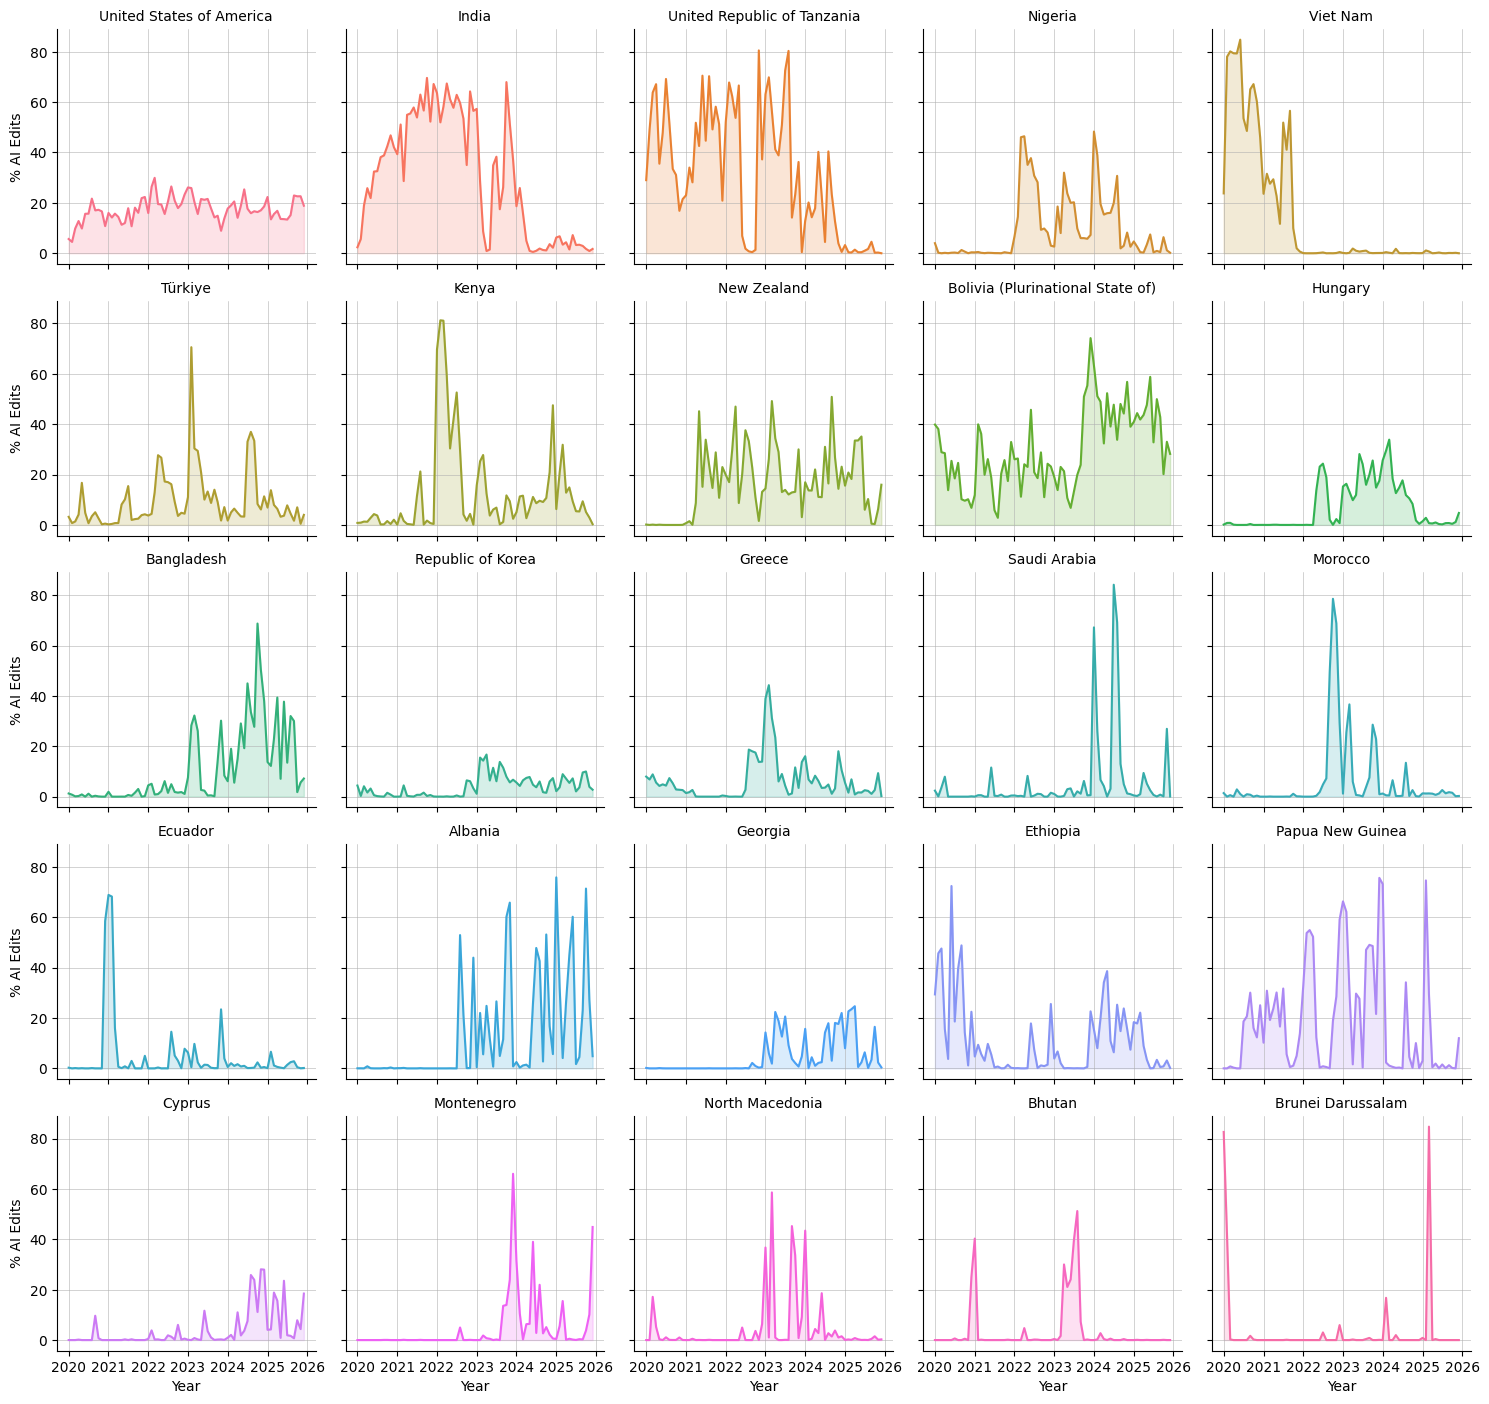

In [106]:
# Create a grid : initialize it
g = sns.FacetGrid(df25, col='nam_en', hue='nam_en', col_wrap=5)

# Add the line over the area with the plot function
g = g.map(plt.plot, 'months', 'edits_perc')
 
# Fill the area with fill_between
g = g.map(plt.fill_between, 'months', 'edits_perc', alpha=0.2).set_titles("{col_name} ")
 
# Control the title of each facet
g = g.set_titles("{col_name}")
#g.set(xlim=(2020, 2026), ylim=(0, 100))
g.set_axis_labels("Year", "% AI Edits")

for ax in g.axes.flat:
    ax.grid(which='major', linewidth=0.4)
    ax.grid(which='minor', linewidth=0.2)
    # Show only yearly labels on x-axis
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Add a title for the whole plot
plt.subplots_adjust(top=0.92)
#g.fig.suptitle('Share of AI-assisted Edits', fontsize=12, fontweight="bold")

g.fig.savefig("../results/top25_share_ai_edits_final_final.png", bbox_inches="tight")
plt.show()

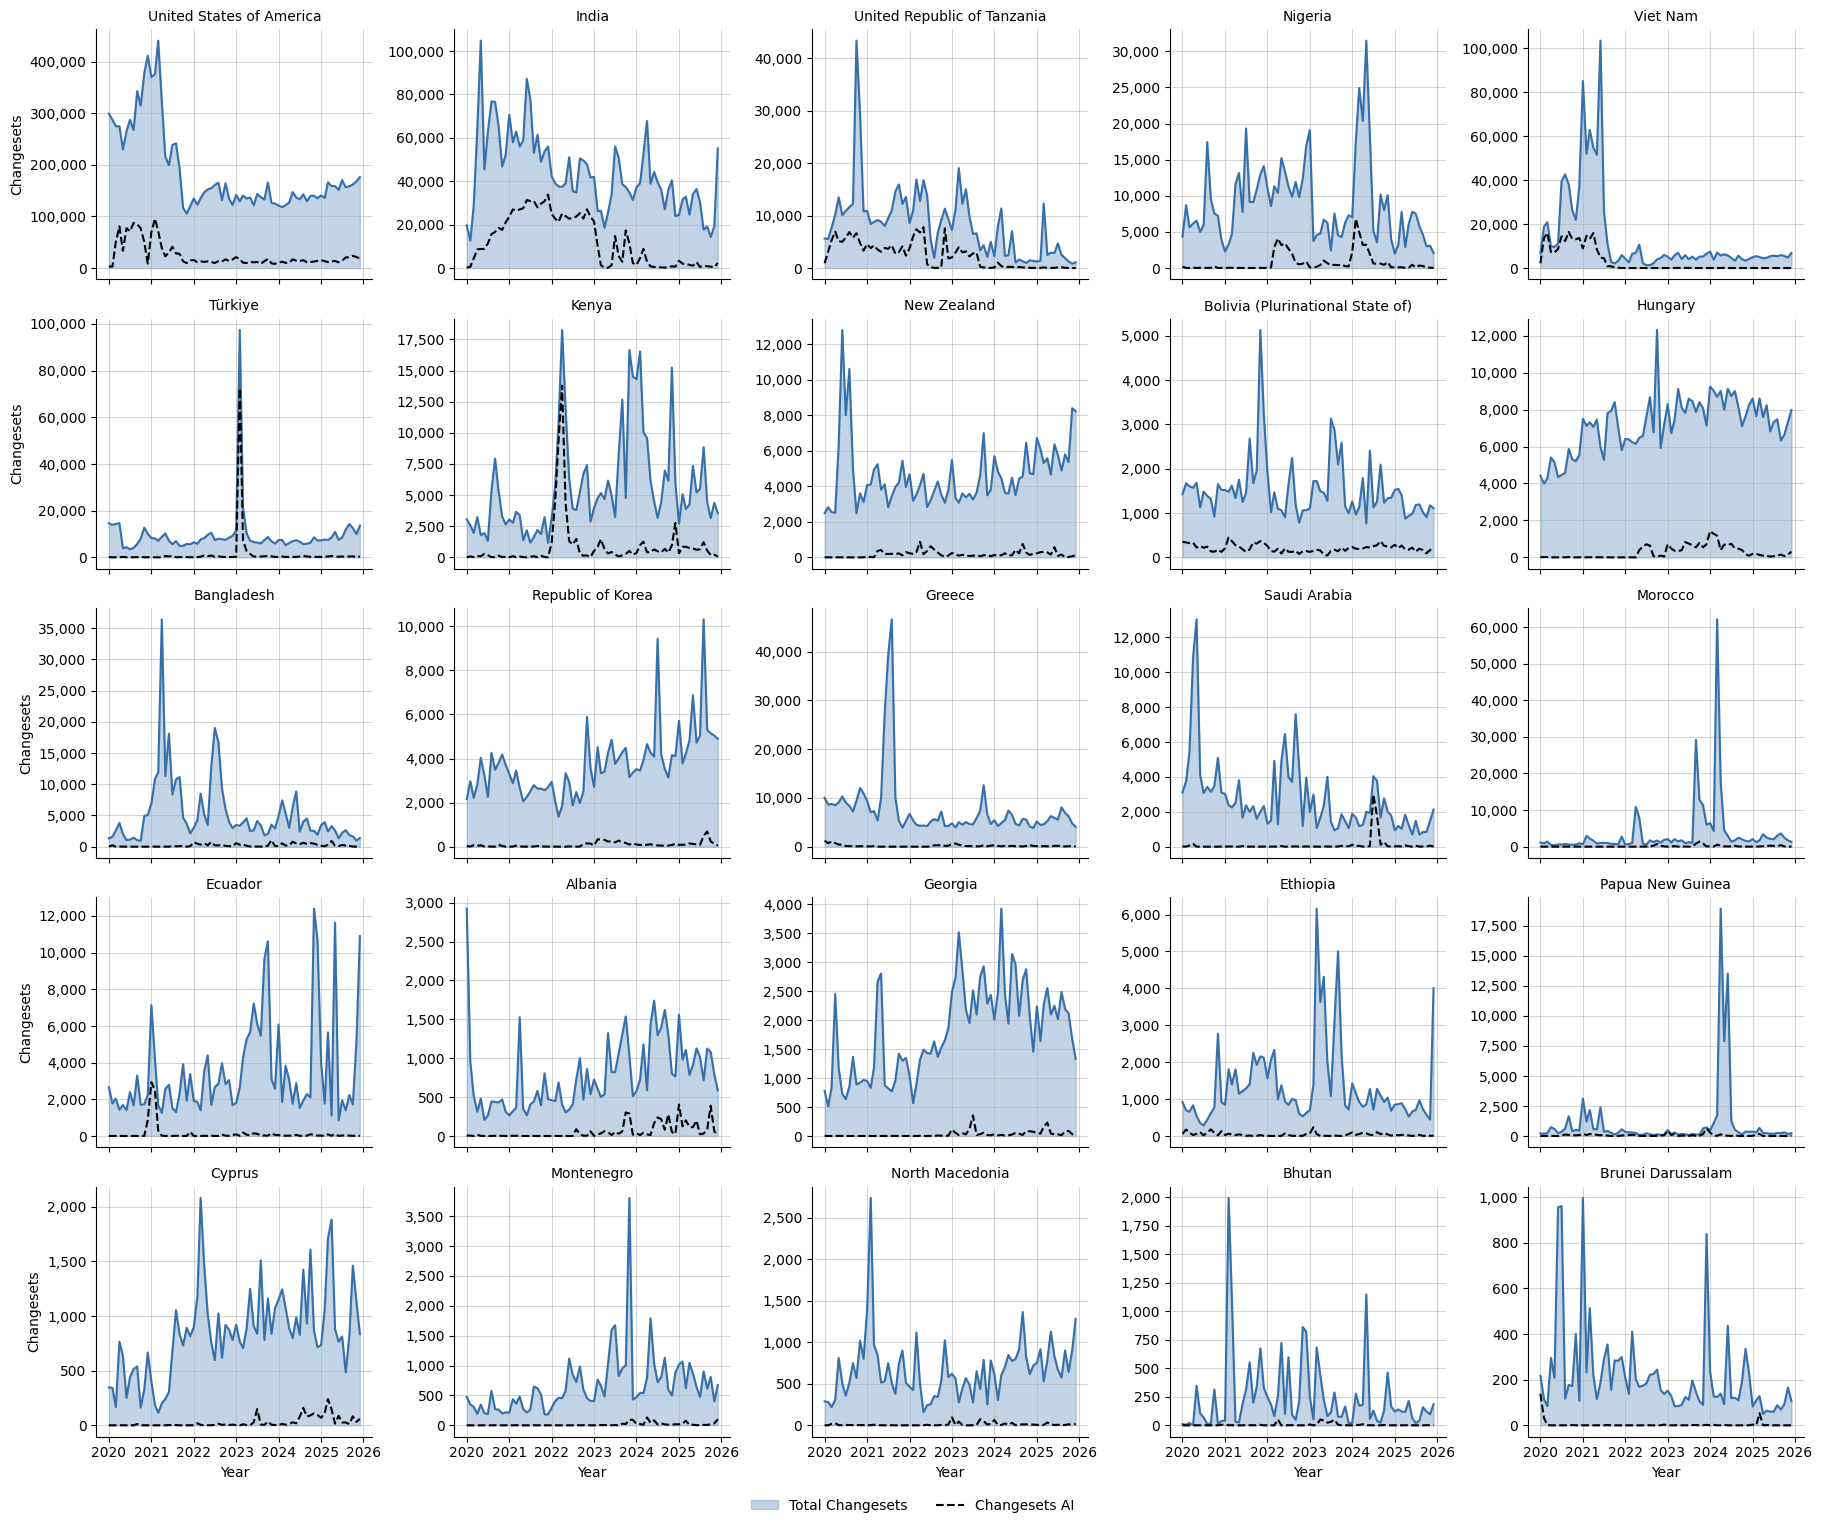

In [110]:
def plot_country(data, **kwargs):
    ax = plt.gca()
    ax.fill_between(data['months'], data['Changesets'], alpha=0.3, label='Total Changesets', color = "#3670AB")
    ax.plot(data['months'], data['Changesets'], linewidth=1.5, color = "#3670AB")
    ax.plot(data['months'], data['ChangesetsAI'], linewidth=1.5, linestyle='--', color='black', label='Changesets AI')

g = sns.FacetGrid(df25, col='nam_en', col_wrap=5, sharey=False)
g.map_dataframe(plot_country)

g.set_titles("{col_name}")
g.set_axis_labels("Year", "Changesets")
#g.set(xlim=(2020, ), ylim=(0, 100))

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(which='major', linewidth=0.4)
    ax.grid(which='minor', linewidth=0.2, )
    
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

#g.fig.suptitle('Total Changesets vs AI Changesets')
plt.subplots_adjust(top=0.92)

# Add a shared legend
g.add_legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
g.fig.savefig("../results/top25_total_ai_changesets_final_final.png", bbox_inches="tight")
plt.show()

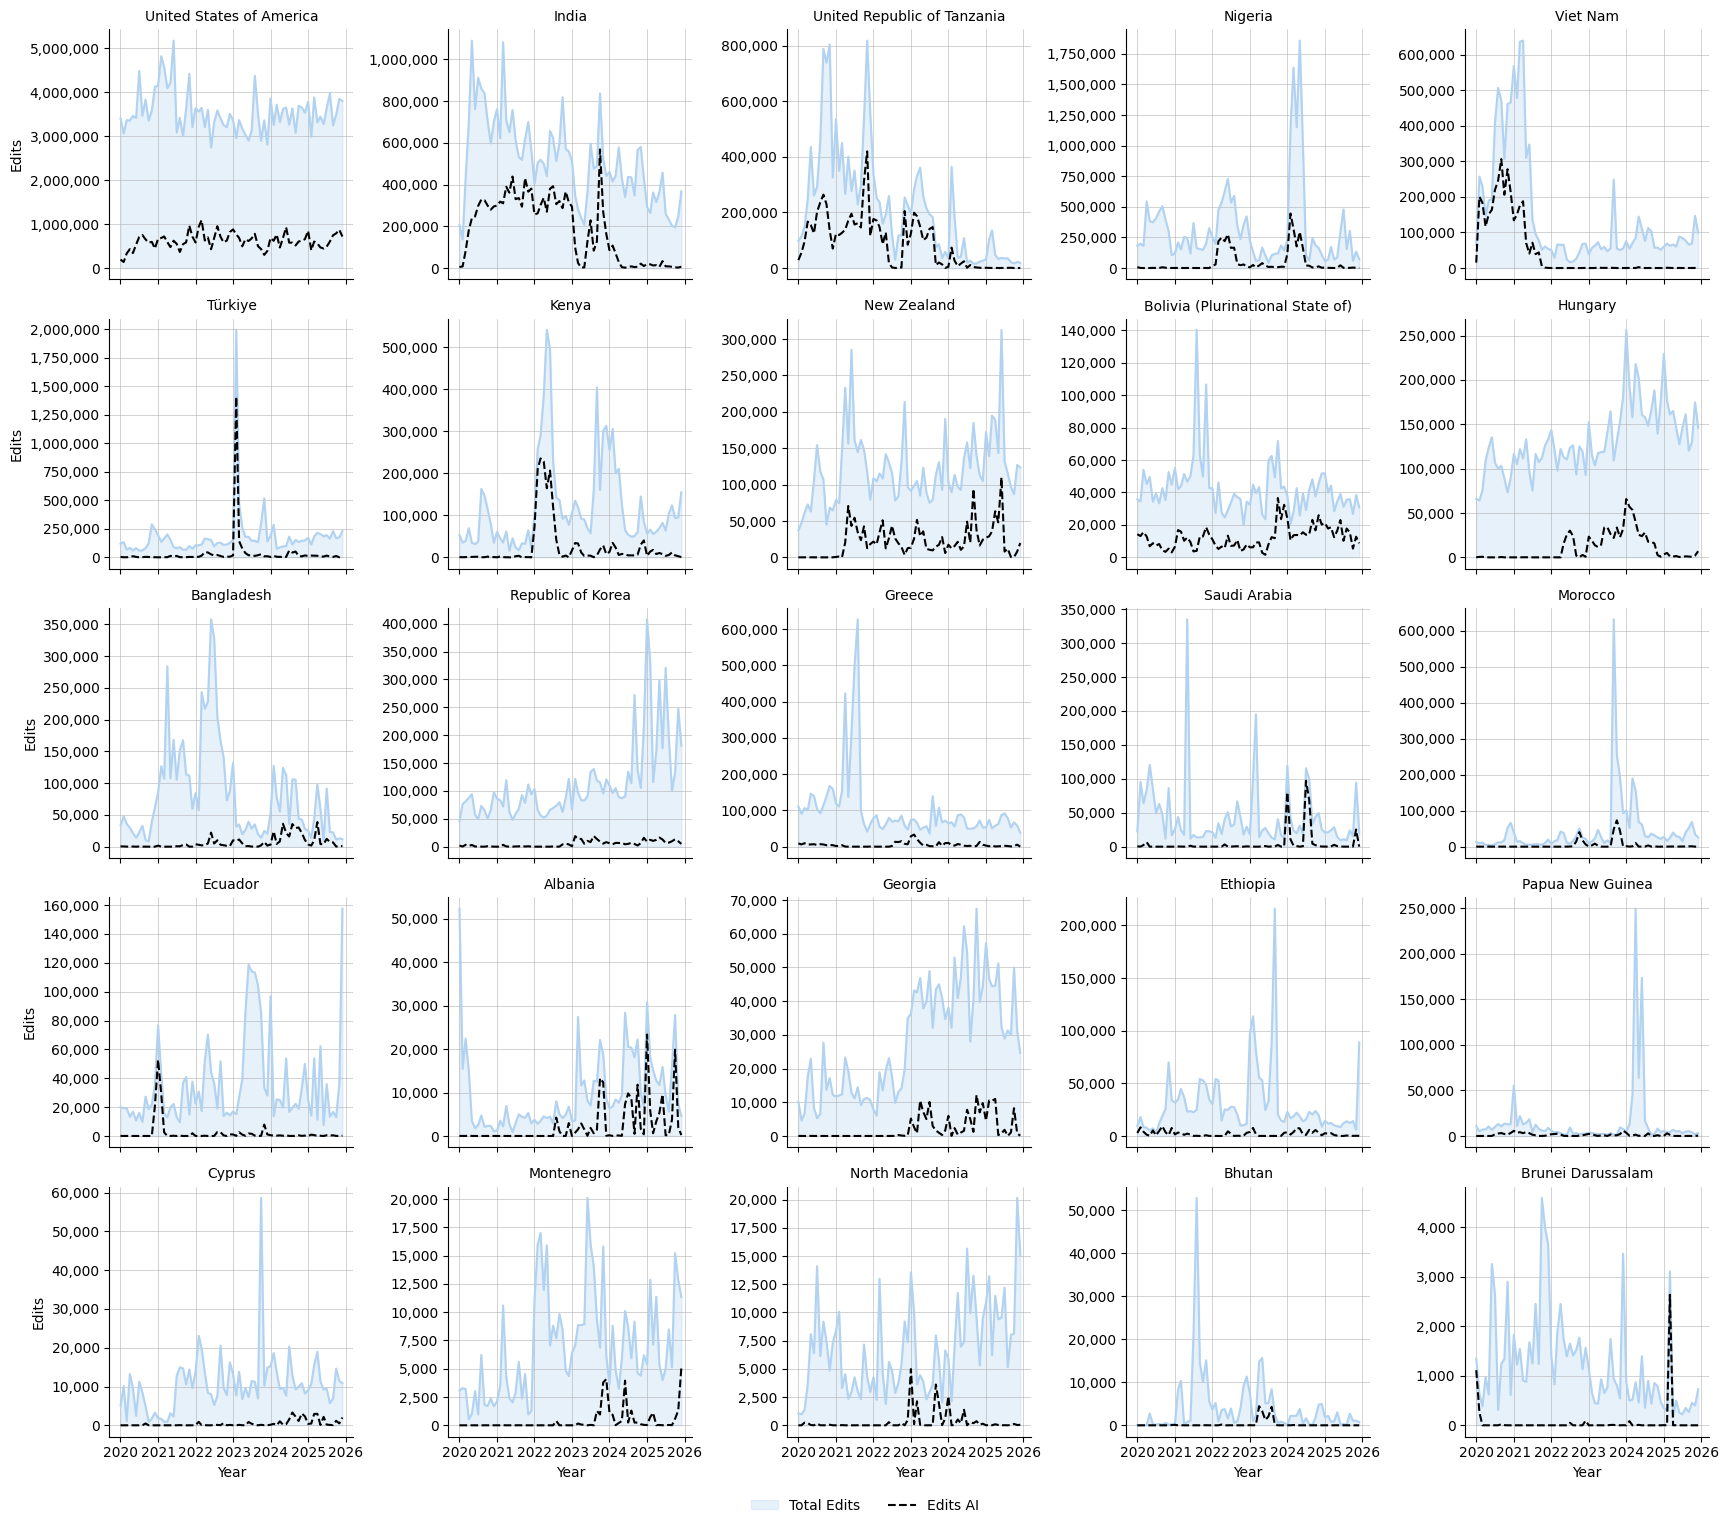

In [117]:
def plot_country(data, **kwargs):
    ax = plt.gca()
    ax.fill_between(data['months'], data['Edits'], alpha=0.3, label='Total Edits', color = "#B1D2F1")
    ax.plot(data['months'], data['Edits'], linewidth=1.5, color = "#B1D2F1")
    ax.plot(data['months'], data['EditsAI'], linewidth=1.5, linestyle='--', color='black', label='Edits AI')

g = sns.FacetGrid(df25, col='nam_en', col_wrap=5, sharey=False)
g.map_dataframe(plot_country)

g.set_titles("{col_name}")
g.set_axis_labels("Year", "Edits")
#g.set(xlim=(2020, ), ylim=(0, 100))

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(which='major', linewidth=0.4)
    ax.grid(which='minor', linewidth=0.2, )
    
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

#g.fig.suptitle('Total Changesets vs AI Changesets')
plt.subplots_adjust(top=0.92)

# Add a shared legend
g.add_legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
g.fig.savefig("../results/top25_total_ai_edits_final_final.png", bbox_inches="tight")
plt.show()

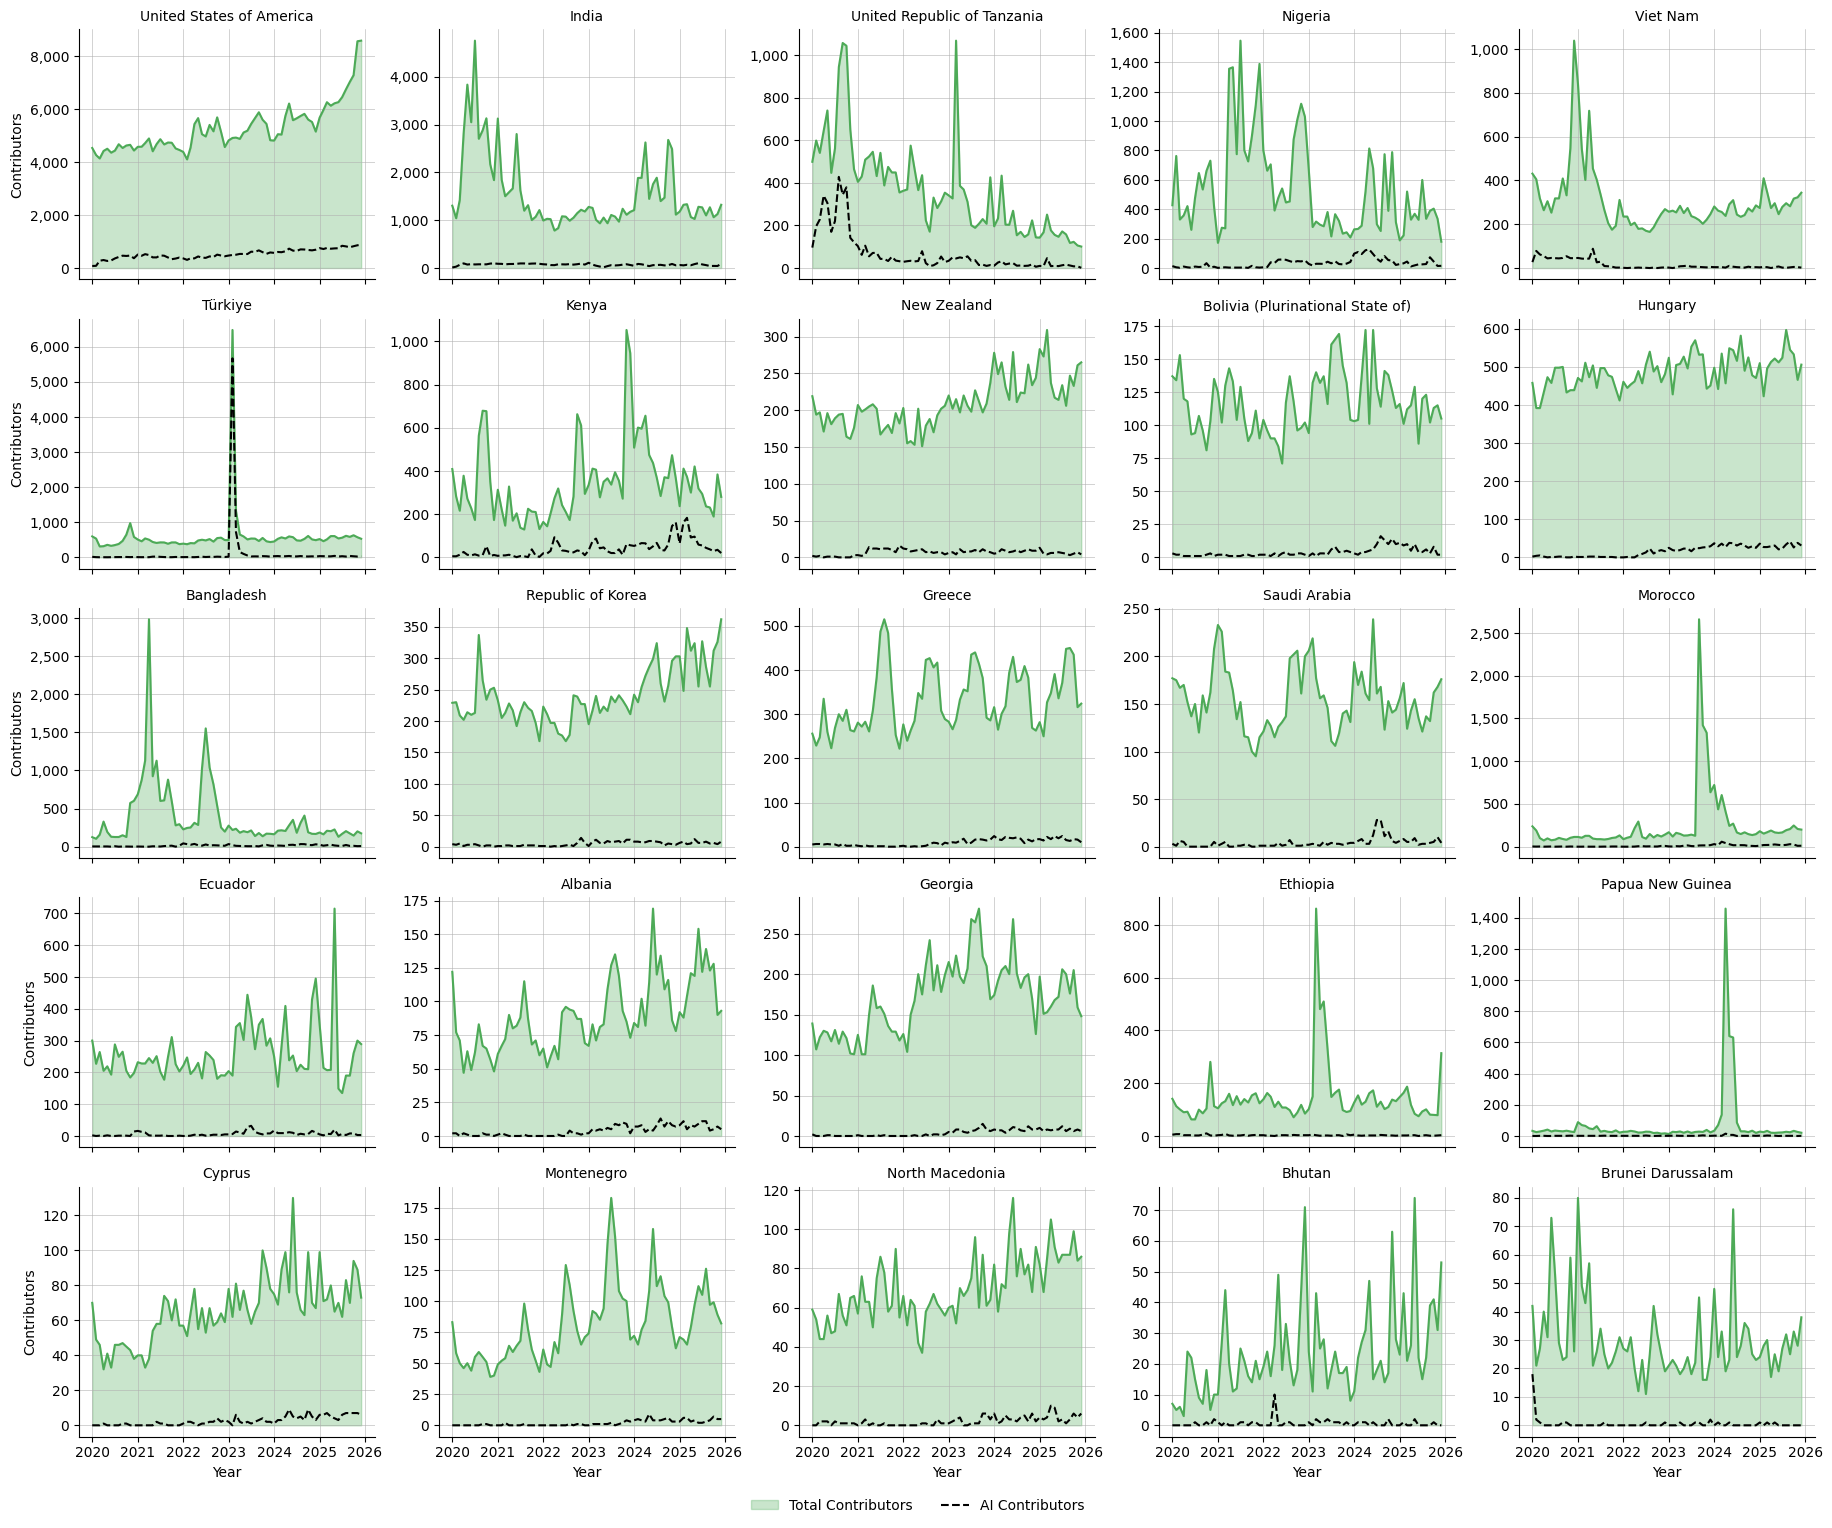

In [115]:
def plot_country(data, **kwargs):
    ax = plt.gca()
    ax.fill_between(data['months'], data['Contributors'], alpha=0.3, label='Total Contributors', color = "#4DAA57")
    ax.plot(data['months'], data['Contributors'], linewidth=1.5, color = "#4DAA57")
    ax.plot(data['months'], data['ContributorsAI'], linewidth=1.5, linestyle='--', color='black', label='AI Contributors')

g = sns.FacetGrid(df25, col='nam_en', col_wrap=5, sharey=False)
g.map_dataframe(plot_country)

g.set_titles("{col_name}")
g.set_axis_labels("Year", "Contributors")
#g.set(xlim=(2020, 2026), ylim=(0, 100))

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(which='major', linewidth=0.4)
    ax.grid(which='minor', linewidth=0.2)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

#g.fig.suptitle('Total Contributors vs AI Contributors')
plt.subplots_adjust(top=0.92)

# Add a shared legend
g.add_legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
g.fig.savefig("../results/top25_total_ai_contributors_finalfinal.png", bbox_inches="tight")
plt.show()

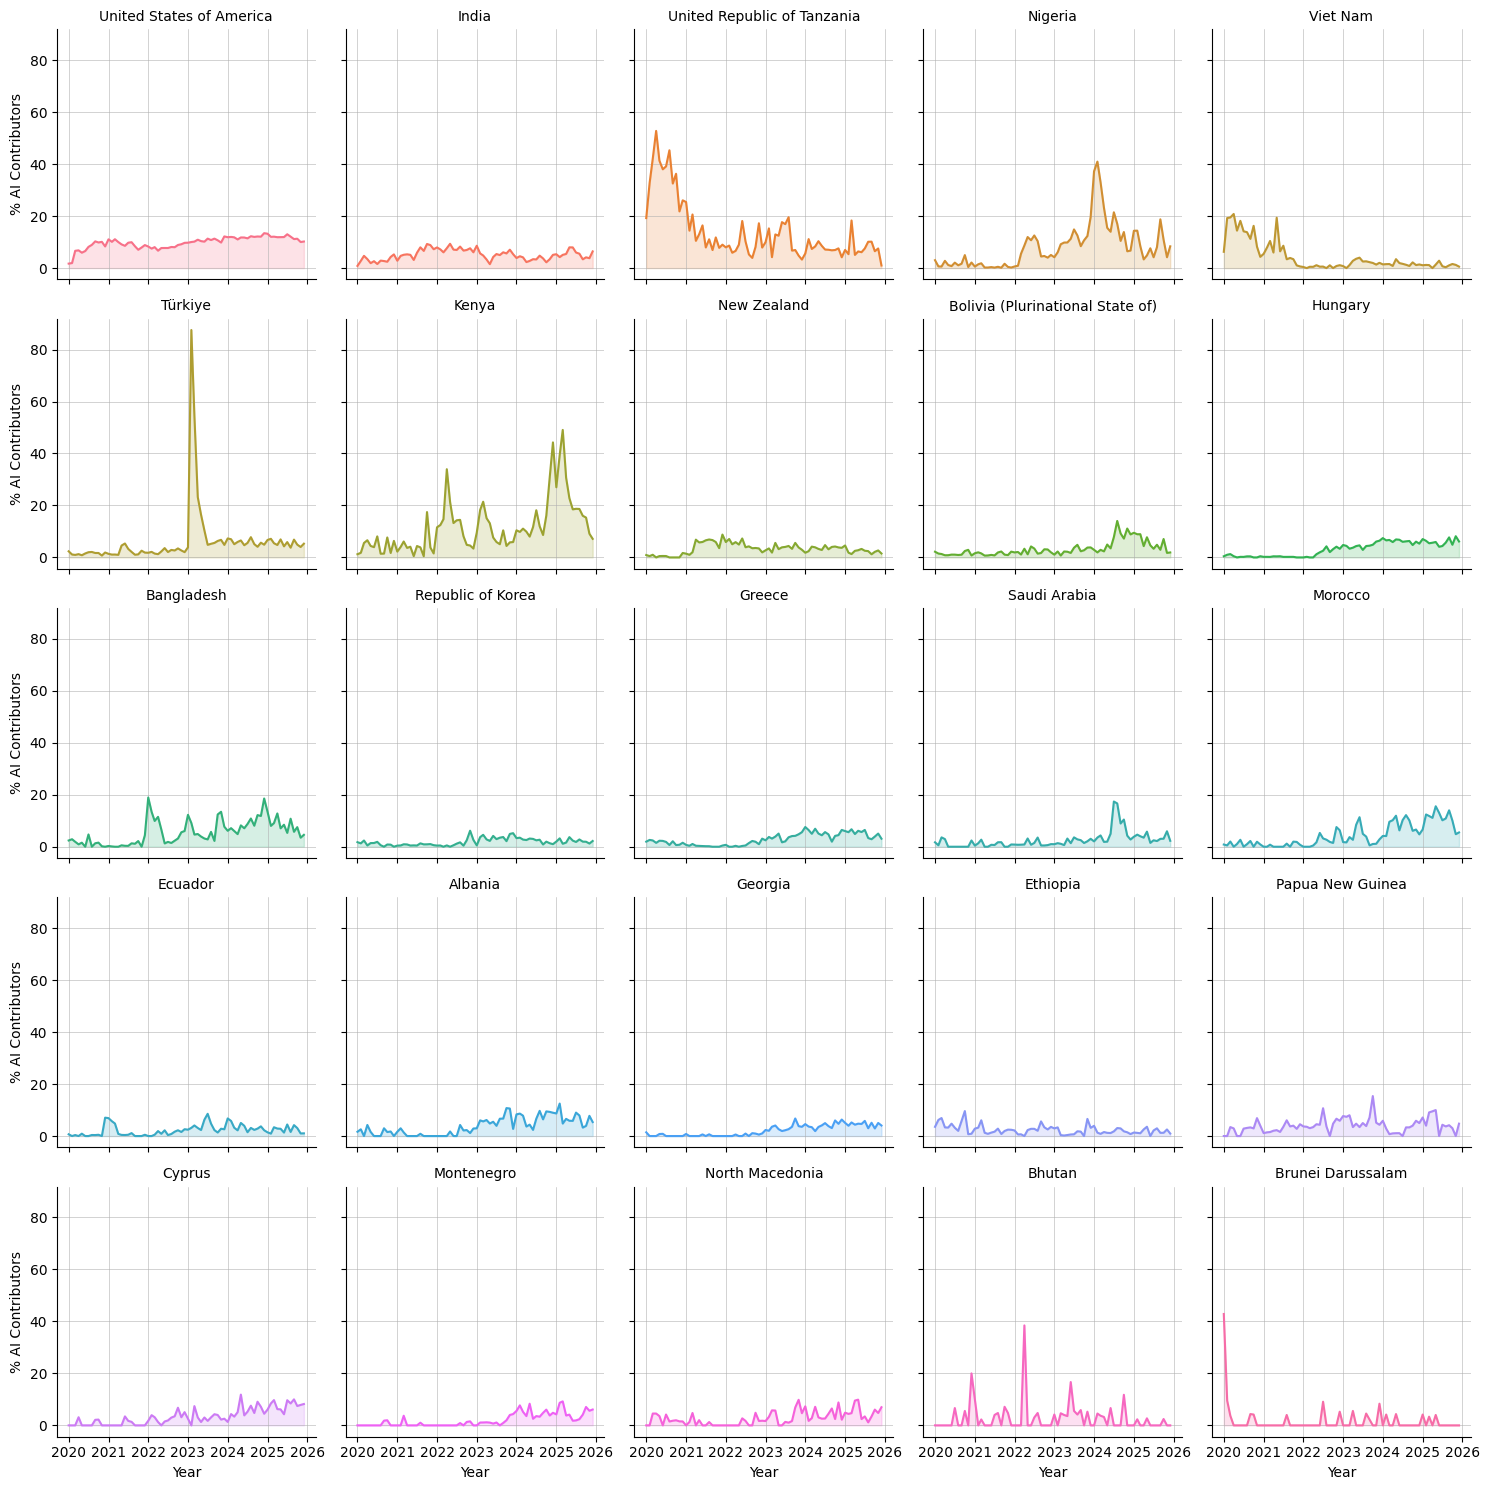

In [118]:
# Create a grid : initialize it
g = sns.FacetGrid(df25, col='nam_en', hue='nam_en', col_wrap=5)

# Add the line over the area with the plot function
g = g.map(plt.plot, 'months', 'contributorsPerc')
 
# Fill the area with fill_between
g = g.map(plt.fill_between, 'months', 'contributorsPerc', alpha=0.2).set_titles("{col_name} ")
 
# Control the title of each facet
g = g.set_titles("{col_name}")
#g.set(xlim=(2020, 2026), ylim=(0, 100))
g.set_axis_labels("Year", "% AI Contributors")

for ax in g.axes.flat:
    ax.grid(which='major', linewidth=0.4)
    ax.grid(which='minor', linewidth=0.2)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


# Add a title for the whole plot
#plt.subplots_adjust(top=0.92)
#g.fig.suptitle('Share of Contributors using AI-assisted mapping', fontsize=12, fontweight="bold")

g.fig.savefig("../results/top25_share_ai_contributor_final_final.png", bbox_inches="tight")

# Show the graph
plt.show()